In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Generate a dataset for practice**

In [24]:
np.random.seed(42)

data = {
    "OrderID": np.arange(1, 101),
    "CustomerName": np.random.choice(
        ["Alice", "Bob", "Charlie", "Diana", "Eve", "Frank"], size=100
    ),
    "Product": np.random.choice(
        ["Laptop", "Tablet", "Smartphone", "Monitor", "Keyboard"], size=100
    ),
    "Category": np.random.choice(["Electronics", "Accessories"], size=100),
    "Quantity": np.random.randint(1, 10, size=100),
    "Price": np.random.uniform(50, 1500, size=100).round(2),
    "OrderDate": pd.date_range(start="2023-01-01", periods=100, freq="D").to_list(),
    "Region": np.random.choice(["North", "South", "East", "West"], size=100),
}

In [25]:
# Create a DataFrame
sales_data = pd.DataFrame(data)

# Save the dataset to a CSV file
file_path = "\\Users\tmhom\Downloads\sales_dataset.csv"
sales_data.to_csv(file_path, index=False)

file_path

'\\Users\tmhom\\Downloads\\sales_dataset.csv'

In [26]:
sales_data.head()

,OrderID,CustomerName,Product,Category,Quantity,Price,OrderDate,Region
0,1,Diana,Keyboard,Accessories,3,90.04,2023-01-01,South
1,2,Eve,Laptop,Accessories,4,889.35,2023-01-02,North
2,3,Charlie,Laptop,Accessories,8,685.79,2023-01-03,East
3,4,Eve,Laptop,Accessories,6,1024.44,2023-01-04,North
4,5,Eve,Laptop,Electronics,8,525.82,2023-01-05,West


In [27]:
sales_data.info()
sales_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   OrderID       100 non-null    int64         
 1   CustomerName  100 non-null    object        
 2   Product       100 non-null    object        
 3   Category      100 non-null    object        
 4   Quantity      100 non-null    int64         
 5   Price         100 non-null    float64       
 6   OrderDate     100 non-null    datetime64[ns]
 7   Region        100 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 6.4+ KB


,OrderID,Quantity,Price,OrderDate
count,100.000000,100.000000,100.000000,100
mean,50.500000,4.700000,750.439400,2023-02-19 12:00:00
min,1.000000,1.000000,72.190000,2023-01-01 00:00:00
25%,25.750000,2.750000,388.555000,2023-01-25 18:00:00
50%,50.500000,4.000000,718.405000,2023-02-19 12:00:00
75%,75.250000,7.000000,1069.757500,2023-03-16 06:00:00
max,100.000000,9.000000,1473.670000,2023-04-10 00:00:00
std,29.011492,2.653376,427.034685,NaN


In [63]:
#Checking the integrity of data

missing_values = sales_data.isnull().sum()
sales_data['OrderDate'] = pd.to_datetime(sales_data['OrderDate'], '%d-%m-%y')

missing_values
sales_data['OrderDate'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 100 entries, 0 to 99
Series name: OrderDate
Non-Null Count  Dtype         
--------------  -----         
100 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 928.0 bytes


In [61]:
high_quantity_orders = sales_data[sales_data['Quantity'] > 5].sort_values('OrderID')
high_quantity_orders.head()

,OrderID,CustomerName,Product,Category,Quantity,Price,OrderDate,Region,TotalCost
2,3,Charlie,Laptop,Accessories,8,685.79,2023-01-03,East,5486.32
3,4,Eve,Laptop,Accessories,6,1024.44,2023-01-04,North,6146.64
4,5,Eve,Laptop,Electronics,8,525.82,2023-01-05,West,4206.56
6,7,Charlie,Smartphone,Accessories,8,1473.67,2023-01-07,North,11789.36
9,10,Eve,Smartphone,Electronics,8,412.86,2023-01-10,North,3302.88


In [60]:
orders_alice = sales_data[sales_data['CustomerName'] == 'Alice'].sort_values('OrderID')
orders_alice

,OrderID,CustomerName,Product,Category,Quantity,Price,OrderDate,Region,TotalCost
21,22,Alice,Laptop,Electronics,6,1064.29,2023-01-22,South,6385.74
27,28,Alice,Laptop,Accessories,1,628.29,2023-01-28,South,628.29
28,29,Alice,Smartphone,Electronics,5,678.61,2023-01-29,West,3393.05
40,41,Alice,Smartphone,Electronics,6,315.16,2023-02-10,North,1890.96
45,46,Alice,Keyboard,Accessories,2,681.73,2023-02-15,South,1363.46
48,49,Alice,Keyboard,Accessories,1,870.75,2023-02-18,East,870.75
53,54,Alice,Monitor,Electronics,1,186.53,2023-02-23,North,186.53
64,65,Alice,Smartphone,Accessories,1,1426.26,2023-03-06,South,1426.26
86,87,Alice,Monitor,Electronics,7,349.69,2023-03-28,South,2447.83
93,94,Alice,Smartphone,Electronics,9,1000.80,2023-04-04,East,9007.20


In [59]:
sales_data['TotalCost'] = sales_data['Quantity'] * sales_data['Price']
sales_data.head()

,OrderID,CustomerName,Product,Category,Quantity,Price,OrderDate,Region,TotalCost
0,1,Diana,Keyboard,Accessories,3,90.04,2023-01-01,South,270.12
1,2,Eve,Laptop,Accessories,4,889.35,2023-01-02,North,3557.40
2,3,Charlie,Laptop,Accessories,8,685.79,2023-01-03,East,5486.32
3,4,Eve,Laptop,Accessories,6,1024.44,2023-01-04,North,6146.64
4,5,Eve,Laptop,Electronics,8,525.82,2023-01-05,West,4206.56


In [71]:
sales_data['Month'] = sales_data['OrderDate'].dt.month
sales_data['Month'].unique()

array([1, 2, 3, 4], dtype=int32)

In [75]:
total_revenue_by_region = sales_data.groupby('Region')['TotalCost'].sum()
total_revenue_by_region

Region
East      77124.69
North    125697.27
South     57508.98
West      92816.43
Name: TotalCost, dtype: float64

In [78]:
avg_price_by_category = sales_data.groupby('Category')['Price'].mean()
avg_price_by_category

Category
Accessories    723.321346
Electronics    779.817292
Name: Price, dtype: float64

In [79]:
sorted_data = sales_data.sort_values('TotalCost', ascending=False)
sorted_data

,OrderID,CustomerName,Product,Category,Quantity,Price,OrderDate,Region,TotalCost,Month
6,7,Charlie,Smartphone,Accessories,8,1473.67,2023-01-07,North,11789.36,1
74,75,Frank,Keyboard,Accessories,8,1419.16,2023-03-16,North,11353.28,3
84,85,Frank,Smartphone,Electronics,9,1239.62,2023-03-26,South,11156.58,3
75,76,Eve,Laptop,Electronics,8,1307.44,2023-03-17,West,10459.52,3
58,59,Diana,Keyboard,Electronics,9,1156.88,2023-02-28,West,10411.92,2
...,...,...,...,...,...,...,...,...,...,...
0,1,Diana,Keyboard,Accessories,3,90.04,2023-01-01,South,270.12,1
57,58,Diana,Laptop,Accessories,3,74.88,2023-02-27,East,224.64,2
53,54,Alice,Monitor,Electronics,1,186.53,2023-02-23,North,186.53,2
35,36,Frank,Laptop,Accessories,1,134.38,2023-02-05,North,134.38,2


In [82]:
top_customers = sales_data.groupby('CustomerName')['TotalCost'].sum().nlargest(5)
top_customers

CustomerName
Diana      76647.71
Eve        71827.00
Frank      70759.16
Charlie    56738.60
Bob        47267.08
Name: TotalCost, dtype: float64

**Visualization**

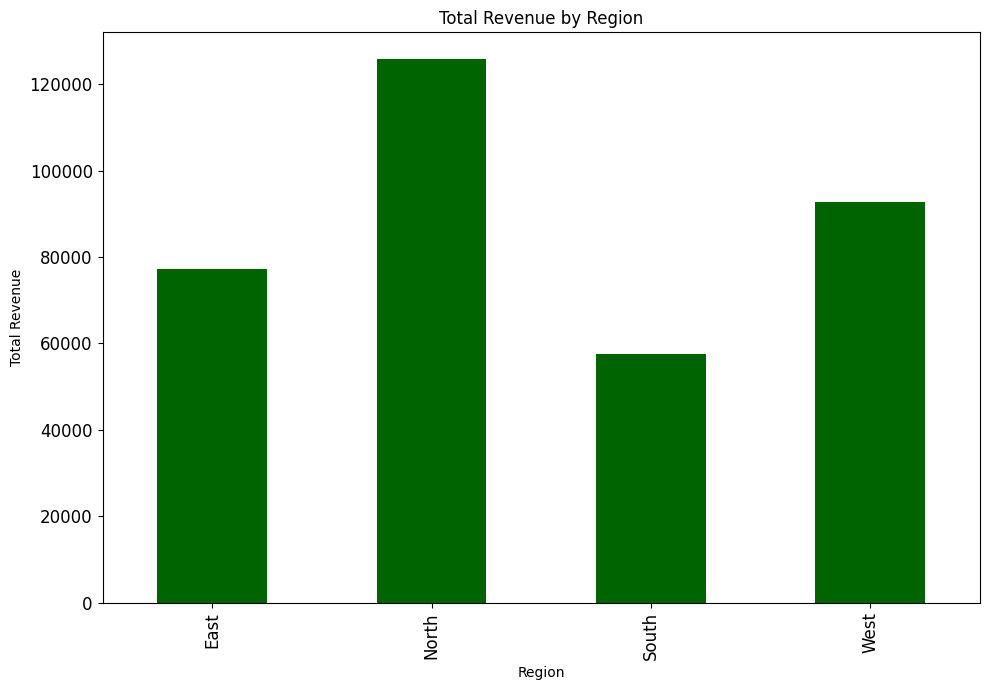

In [106]:
plt.figure(figsize=(10, 7))
total_revenue_by_region.plot(kind='bar', color='darkgreen', title='Total Revenue by Region', legend=False)
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


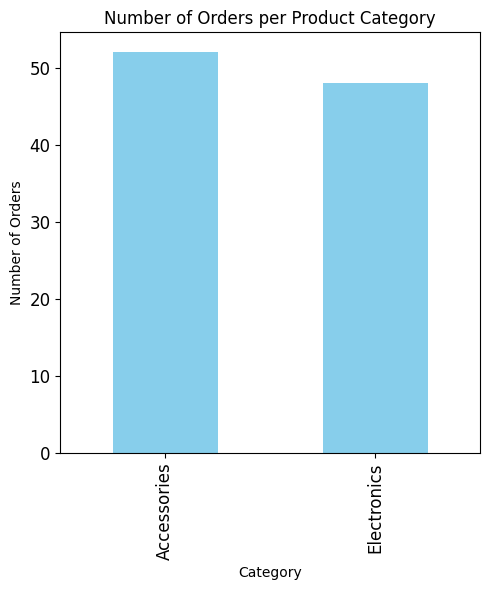

In [110]:
plt.figure(figsize=(5, 6))
order_count_by_category = sales_data['Category'].value_counts()
order_count_by_category.plot(kind='bar', color='skyblue', title='Number of Orders per Product Category', legend=False)
plt.xlabel('Category')
plt.ylabel('Number of Orders')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

In [111]:
most_purchased_product = sales_data.groupby('Product')['Quantity'].sum().idxmax()
print(f"Most purchased product: {most_purchased_product}")

Most purchased product: Laptop


In [112]:
# Total revenue in the first quarter of 2023
first_quarter_revenue = sales_data[(sales_data['OrderDate'] >= '2023-01-01') & (sales_data['OrderDate'] <= '2023-03-31')]['TotalCost'].sum()
print(f"Total revenue in Q1 2023: {first_quarter_revenue}")

Total revenue in Q1 2023: 311596.66000000003
